In [ ]:
import pandas as pd
df = pd.read_csv('co2.csv')
print(df.columns.tolist())
print(df.head())

['engine', 'cylandr', 'fuelcomb', 'out1']
   engine  cylandr  fuelcomb  out1
0     2.0        4       8.5   196
1     2.4        4       9.6   221
2     1.5        4       5.9   136
3     3.5        6      11.1   255
4     3.5        6      10.6   244


In [ ]:
import numpy as np
import seaborn as sns
from sklearn import linear_model
import sklearn.metrics as sm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
x = df[['fuelcomb']]
y = df['out1']

print(x.head())
print(y.head())

   fuelcomb
0       8.5
1       9.6
2       5.9
3      11.1
4      10.6
0    196
1    221
2    136
3    255
4    244
Name: out1, dtype: int64


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("Train size:", len(x_train))
print("Test size:", len(x_test))

Train size: 400
Test size: 100


In [ ]:
model = linear_model.LinearRegression()
model.fit(x_train, y_train)

print("ضریب (شیب خط):", model.coef_)
print("عرض از مبدا:", model.intercept_)

ضریب (شیب خط): [14.24938646]
عرض از مبدا: 90.71902497485078


In [ ]:
y_pred = model.predict(x_test)
print(y_pred[:5])

[318.70920827 325.8339015  340.08328795 226.08819631 271.68623296]


In [ ]:
print("MAE:", sm.mean_absolute_error(y_test, y_pred))
print("MSE:", sm.mean_squared_error(y_test, y_pred))
print("R2 Score:", sm.r2_score(y_test, y_pred))

MAE: 31.864421574695733
MSE: 1510.2567154534015
R2 Score: 0.7474395703126445


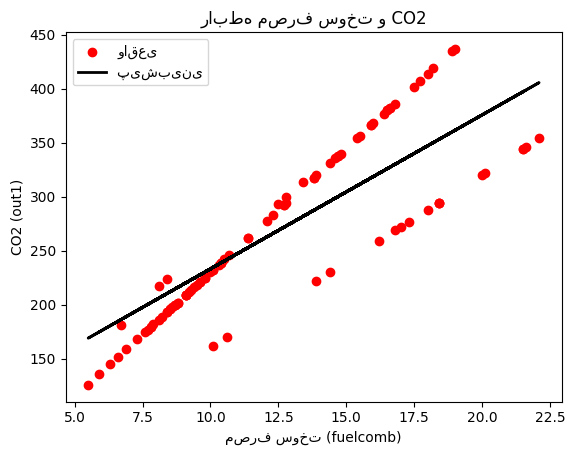

In [ ]:
plt.scatter(x_test, y_test, color='red', label='واقعی')
plt.plot(x_test, y_pred, color='black', linewidth=2, label='پیش‌بینی')
plt.xlabel('مصرف سوخت (fuelcomb)')
plt.ylabel('CO2 (out1)')
plt.title('رابطه مصرف سوخت و CO2')
plt.legend()
plt.show()

In [ ]:
new_fuel = np.array([[12]])
co2_pred = model.predict(new_fuel)
print(f"CO2 پیش‌بینی شده برای مصرف 12: {co2_pred[0]:.2f}")

CO2 پیش‌بینی شده برای مصرف 12: 261.71


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
new_fuel = pd.DataFrame([[12]], columns=['fuelcomb'])
co2_pred = model.predict(new_fuel)
print(f"CO2 پیش‌بینی شده برای مصرف 12: {co2_pred[0]:.2f}")

CO2 پیش‌بینی شده برای مصرف 12: 261.71
